In [3]:
import matplotlib.pyplot as plt
from helper import load_bike, load_bike_hourly

df = load_bike()
df.shape

(8760, 17)

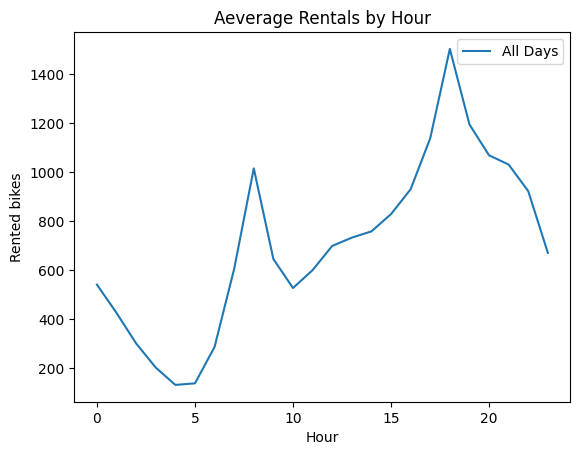

In [8]:
hourly = df.groupby('hour')['rented'].mean()
fig, ax = plt.subplots()
ax.plot(hourly.index, hourly.values, label='All Days')
ax.set_title('Aeverage Rentals by Hour')
ax.set_xlabel('Hour')
ax.set_ylabel('Rented bikes')
ax.legend()
plt.show()

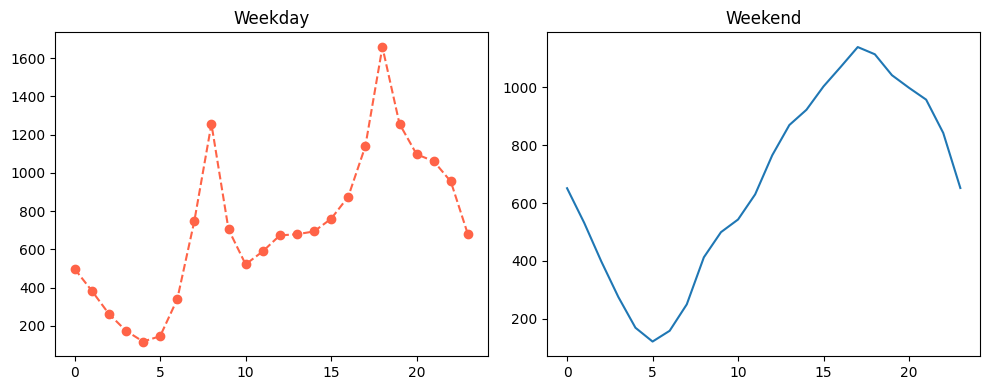

In [12]:
weekday = df[df['is_weekend'] == False].groupby('hour')['rented'].mean()
weekend = df[df['is_weekend'] == True].groupby('hour')['rented'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # 1행 2열
axes[0].plot(weekday.index, weekday.values, color='tomato', linestyle='--', marker='o')
axes[0].set_title('Weekday')
axes[1].plot(weekend.index, weekend.values)
axes[1].set_title('Weekend')
plt.tight_layout()

# 문제1. 시간대별 최대 대여 수를 선으로 그리고, 제목을 Max Rentrals by Hour 로 만드세요
# 문제2. 봄과 가을의 시간대별 평균을 한 액자에 그리고 범례(legend) 를 붙이세요 <- plot 하나에 두개의 선이 한번에!


Text(0.5, 1.0, 'Max Tentrals by Hour')

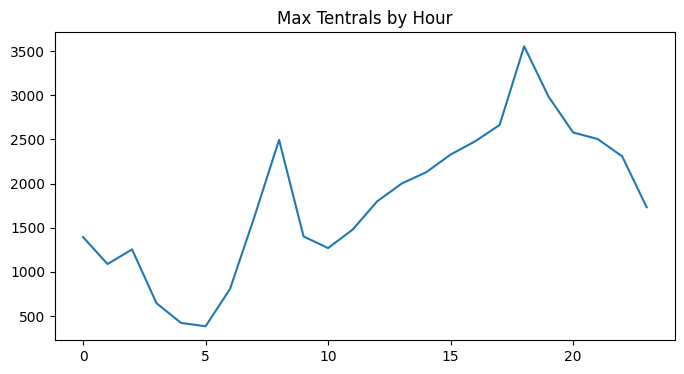

In [14]:
# 문제1. 시간대별 최대 대여 수를 선으로 그리고, 제목을 Max Rentrals by Hour 로 만드세요
hourly_max = df.groupby('hour')['rented'].max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_max.index, hourly_max.values)
ax.set_title('Max Tentrals by Hour')

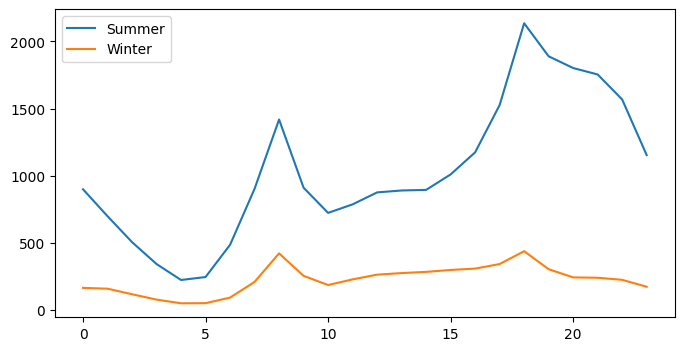

In [23]:
# 문제2. 봄과 가을의 시간대별 평균을 한 액자에 그리고 범례(legend) 를 붙이세요 <- plot 하나에 두개의 선이 한번에!
hourly_season = load_bike_hourly()
summer = hourly_season[hourly_season['season'] == 'Summer']
winter = hourly_season[hourly_season['season'] == 'Winter']
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(summer['hour'], summer['rented'], label='Summer')
ax.plot(winter['hour'], winter['rented'], label='Winter')
ax.legend()

In [25]:
from helper import load_titanic
df = load_titanic()

<BarContainer object of 3 artists>

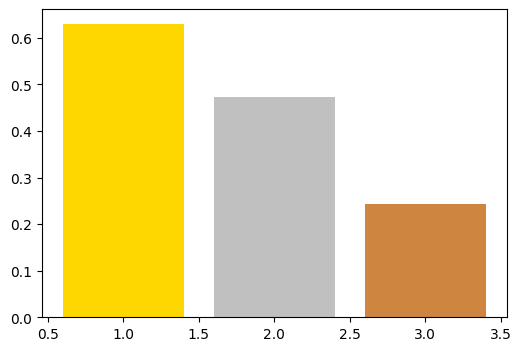

In [28]:
# 등급별 (Pclass) 생존자 평균이
rate = df.groupby('Pclass')['Survived'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rate.index, rate.values, color=['gold', 'silver', 'peru'])

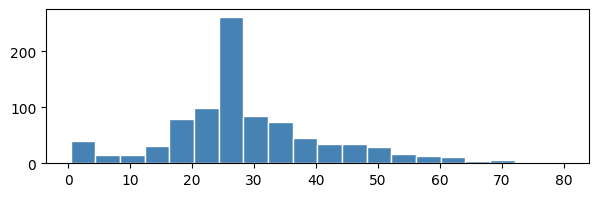

In [36]:
fig, ax = plt.subplots(figsize=(7, 2))
ax.hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
plt.show()

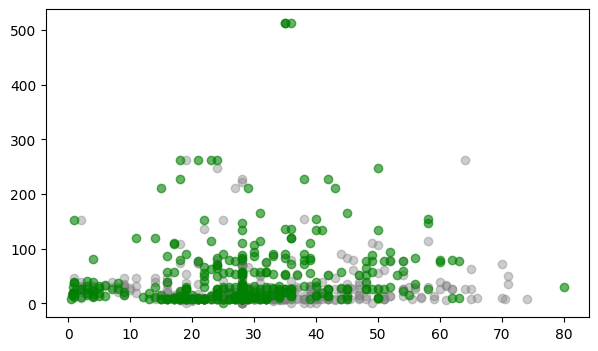

In [37]:
alive = df[df['Survived'] == 1]
dead = df[df['Survived'] == 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dead['Age'], dead['Fare'], color='gray', alpha=0.4, label='Dead')
ax.scatter(alive['Age'], alive['Fare'], color='green', alpha=0.6, label='Alive')